# Air Quality Prediction — Exploratory Data Analysis

## Week 1: Initial Setup and Delhi Data Preparation

This notebook begins the exploratory analysis of the `city_day.csv` dataset. The initial analysis focuses on Delhi.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1. Load Dataset

Load the original `city_day.csv` dataset and preview the first five rows.

In [3]:
df = pd.read_csv("../data/raw/city_day.csv")
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


### 2. Inspect Dataset Structure

Check the dataset dimensions, available columns, and data types.

In [4]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (29531, 16)

Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


### 3. Check Available Cities

List the unique cities in the dataset before selecting Delhi for further analysis.

In [5]:
df["City"].unique()

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

### 4. Filter Delhi Data

Create a separate DataFrame containing only Delhi observations while keeping the original dataset unchanged.

In [6]:
delhi_df = df[df["City"] == "Delhi"].copy()

### 5. Verify Delhi Data

Check the dimensions of the filtered Delhi dataset.

In [7]:
delhi_df.shape

(2009, 16)

### 6. Preview Delhi Data

Preview the first five Delhi observations to verify that the filtering was successful.

In [8]:
delhi_df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
10229,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
10230,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
10231,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate
10232,Delhi,2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34,319.0,Very Poor
10233,Delhi,2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96,325.0,Very Poor


### 7. Parse Date Column

Convert the `Date` column from text into a proper datetime format for time-based analysis.

In [9]:
delhi_df["Date"] = pd.to_datetime(delhi_df["Date"])

### 8. Verify Date Conversion

Confirm that the `Date` column has been successfully converted to a datetime data type.

In [10]:
delhi_df["Date"].dtype

dtype('<M8[ns]')

### 9. Final Data Check

Review the filtered Delhi dataset, including column data types and non-null value counts.

In [11]:
delhi_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2009 entries, 10229 to 12237
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        2009 non-null   object        
 1   Date        2009 non-null   datetime64[ns]
 2   PM2.5       2007 non-null   float64       
 3   PM10        1932 non-null   float64       
 4   NO          2007 non-null   float64       
 5   NO2         2007 non-null   float64       
 6   NOx         2009 non-null   float64       
 7   NH3         2000 non-null   float64       
 8   CO          2009 non-null   float64       
 9   SO2         1899 non-null   float64       
 10  O3          1925 non-null   float64       
 11  Benzene     2009 non-null   float64       
 12  Toluene     2009 non-null   float64       
 13  Xylene      1228 non-null   float64       
 14  AQI         1999 non-null   float64       
 15  AQI_Bucket  1999 non-null   object        
dtypes: datetime64[ns](1), fl

### 10.Check Data Range

Check the earliest and latest dates availabel in the Delhi database.

In [12]:
print("Start date:", delhi_df["Date"].min())
print("End date:", delhi_df["Date"].max())
print("Number of observations:", len(delhi_df))

Start date: 2015-01-01 00:00:00
End date: 2020-07-01 00:00:00
Number of observations: 2009


### 11.Check Duplicate Dates

Check wheter the Delhi dataset contains multiple observations for the same date.

In [13]:
duplicate_count = delhi_df["Date"].duplicated().sum()

print("Number of duplicate dates:", duplicate_count)

Number of duplicate dates: 0


### 12.Check for Missing Calendar Dates

Creates a complete daily date range between the first and last observed dates and compare it with the dates present in the Delhi datset.

In [14]:
full_date_range = pd.date_range(
    start=delhi_df["Date"].min(),
    end=delhi_df["Date"].max(),
    freq="D"
)


In [15]:
existing_dates = pd.DatetimeIndex(delhi_df["Date"])

missing_dates = full_date_range.difference(existing_dates)

In [16]:
print("Expected number of calendar dates:", len(full_date_range))
print("Observed number of dates:", len(existing_dates))
print("Missing calendar dates:", len(missing_dates))

Expected number of calendar dates: 2009
Observed number of dates: 2009
Missing calendar dates: 0


In [17]:
print(missing_dates)

DatetimeIndex([], dtype='datetime64[ns]', freq='D')


### 13.Reindex Delhi Data to Continuous Daily Calender

Reindex the Delhi dataset using the complete daily calendar so that every date between the start and dates is represented.

In [18]:
delhi_daily = (
    delhi_df
    .set_index("Date")
    .reindex(full_date_range)
)

delhi_daily.index.name = "Date"
delhi_daily = delhi_daily.reset_index()

print("Shape after reindexing:", delhi_daily.shape)

Shape after reindexing: (2009, 16)


### 14.Verify Dates Inserted During Reindexing 

Indetify dates that were not present in the original Delhi datset but were added during reindexing.

In [19]:
inserted_dates = full_date_range.difference(existing_dates)

print("Number of dates inserted:", len(inserted_dates))
print("Inserted dates:")
print(inserted_dates)

Number of dates inserted: 0
Inserted dates:
DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq='D')


### 15.Verify Continuous Calender 

Confirm that the reindexed Delhi datset ontains one row for every calender daybetween and end dates.


In [20]:
print("Rows after reindexing:", len(delhi_daily))
print("Expected rows:", len(full_date_range))
print("Calendar is continuous:", len(delhi_daily) == len(full_date_range))

Rows after reindexing: 2009
Expected rows: 2009
Calendar is continuous: True


In [21]:
date_differences = delhi_daily["Date"].diff().dropna()

print("Largest gap:", date_differences.max())
print("Smallest gap:", date_differences.min())

Largest gap: 1 days 00:00:00
Smallest gap: 1 days 00:00:00


## 16. Overall Missing Value Analysis — Ishan

This section examines the amount of missing data in the continuous daily Delhi dataset.  
Both the **number** and **percentage** of missing values are calculated for every column.

> **Week 1 scope:** Missing values are only analyzed here. No imputation, interpolation, forward filling, or row/column removal is performed yet. The missing-data treatment strategy will be decided after the detailed EDA in Week 2.


In [22]:
# Missing-value count and percentage for each column
missing_count = delhi_daily.isnull().sum()
missing_percentage = (missing_count / len(delhi_daily)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percentage.round(2)
})

# Sort from most missing to least missing
missing_table = missing_table.sort_values(
    'Missing Percentage (%)',
    ascending=False
)

missing_table


,Missing Count,Missing Percentage (%)
Xylene,781,38.88
SO2,110,5.48
O3,84,4.18
PM10,77,3.83
AQI,10,0.50
AQI_Bucket,10,0.50
NH3,9,0.45
PM2.5,2,0.10
NO,2,0.10
NO2,2,0.10


## 17. Missingness in Pollutant Columns

Since pollutant readings will later be used for feature engineering and next-day prediction, their missingness is examined separately.


In [23]:
# Important pollutant columns in the dataset
pollutants = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
    'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene'
]

pollutant_missing = missing_table.loc[
    missing_table.index.intersection(pollutants)
].sort_values('Missing Percentage (%)', ascending=False)

pollutant_missing


,Missing Count,Missing Percentage (%)
Xylene,781,38.88
SO2,110,5.48
O3,84,4.18
PM10,77,3.83
NH3,9,0.45
PM2.5,2,0.10
NO,2,0.10
NO2,2,0.10
NOx,0,0.00
CO,0,0.00


## 18. Missingness Visualization

The bar chart below makes it easier to compare missing-data percentages across pollutant variables.


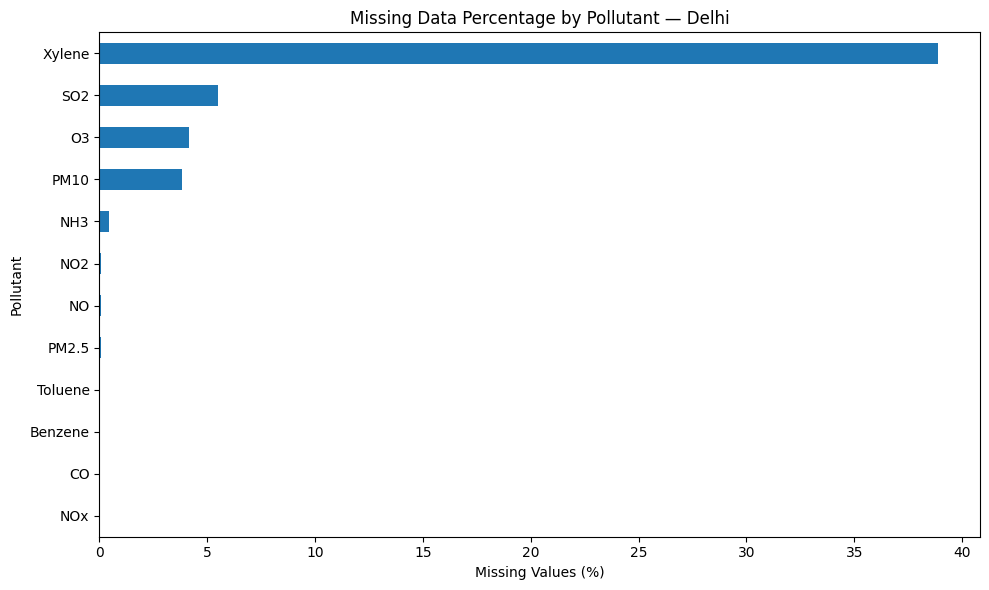

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
pollutant_missing['Missing Percentage (%)'].sort_values().plot(kind='barh')
plt.xlabel('Missing Values (%)')
plt.ylabel('Pollutant')
plt.title('Missing Data Percentage by Pollutant — Delhi')
plt.tight_layout()
plt.show()


## 19. Week 1 Missing-Data Observations — Ishan

- The continuous Delhi calendar contains **2,009 daily rows** from **2015-01-01 to 2020-07-01**.
- Among the pollutant variables, **PM2.5** has the highest missingness, with **2 missing observations (0.10%)**.
- **PM2.5**, the main regression target for the project, has **2 missing observations (0.10%)**.
- **PM10** has **77 missing observations (3.83%)**.
- **Xylene** has the lowest missingness among the pollutant columns examined, at **38.88%**.
- Missingness varies substantially across pollutants, so applying one identical treatment to every column may not be appropriate.
- At this stage, missing values are **not filled or removed**. The team will decide the treatment policy in Week 2 after examining missingness by time period and completing the detailed EDA.


## PM2.5 Exploratory Data Analysis

This section examines the distribution and temporal behaviour of PM2.5 concentrations in Delhi. The aim is to understand the range, variability, and broad patterns in PM2.5 before applying any missing-value treatment or building prediction models.

In [26]:
delhi_df["PM2.5"].describe()

count    2007.000000
mean      117.196153
std        82.912945
min        10.240000
25%        57.095000
50%        94.620000
75%       153.030000
max       685.360000
Name: PM2.5, dtype: float64

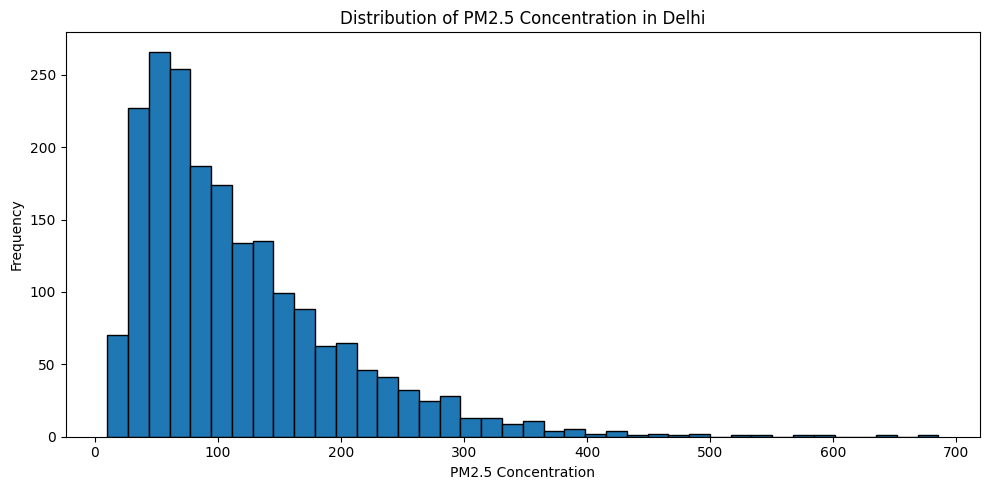

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(delhi_df["PM2.5"].dropna(), bins=40, edgecolor="black")

plt.title("Distribution of PM2.5 Concentration in Delhi")
plt.xlabel("PM2.5 Concentration")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

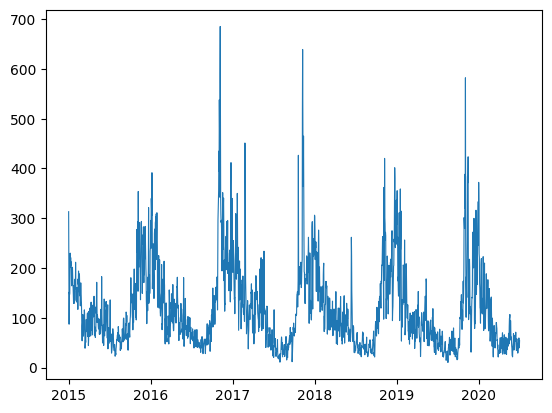

In [32]:
plt.plot(delhi_df["Date"], delhi_df["PM2.5"], linewidth=0.8)

### PM2.5 Observations

The PM2.5 data contains 2007 available observations, with an average concentration of about 117.20 and a median of 94.62. The distribution is right-skewed, as most observations are concentrated at lower values while a few days have very high PM2.5 levels, with the maximum reaching 685.36.

The time-series plot also shows a clear repeating seasonal pattern. PM2.5 levels rise sharply during certain periods of each year and remain comparatively lower during other parts of the year. Several sudden pollution spikes are also visible. These patterns suggest that recent PM2.5 values and seasonal information may be useful when predicting the next day's concentration.